In [1]:
import numpy as np
import os
import torch
import torchvision
from torchvision import datasets
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

random.seed(0)
torch.manual_seed(0)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


Total number of images: 4317
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


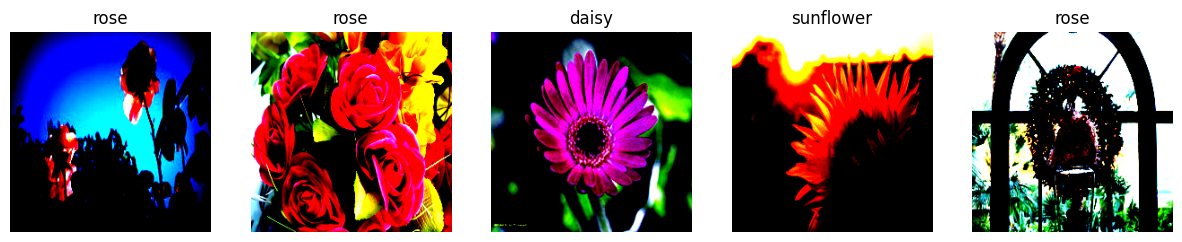

In [3]:
from PIL import Image

# Data path
data_dir = '/kaggle/input/flowers-recognition/flowers'

# Define transformations
prepare_imgs = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((224, 224)),  # Resize images to 224x224
        torchvision.transforms.ToTensor(),  # Convert images to tensor
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]  # Normalize images by channel
        ),
    ]
)

# Using ImageFolder to load dataset
dataset = datasets.ImageFolder(data_dir, transform=prepare_imgs)

# Create a DataLoader for batching
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Check the total number of images and classes
print(f'Total number of images: {len(dataset)}')
print(f'Classes: {dataset.classes}')

# Displaying first batch of images
data_iter = iter(data_loader)
images, labels = next(data_iter)

# Display a few images from the batch
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(images[i].permute(1, 2, 0))  # Convert tensor to HWC for matplotlib
    axes[i].axis('off')
    axes[i].set_title(dataset.classes[labels[i]])
plt.show()

In [4]:
dataset.imgs[2]

('/kaggle/input/flowers-recognition/flowers/daisy/10172379554_b296050f82_n.jpg',
 0)

In [6]:
class ValueMeter(object):
  """
  Вспомогательный класс, чтобы отслеживать loss и метрику
  """
  def __init__(self):
      self.sum = 0
      self.total = 0

  def add(self, value, n):
      self.sum += value*n
      self.total += n

  def value(self):
      return self.sum/self.total

def log(mode, epoch, loss_meter, accuracy_meter, best_perf=None):
  """
  Вспомогательная функция, чтобы
  """
  print(
      f"[{mode}] Epoch: {epoch:0.2f}. "
      f"Loss: {loss_meter.value():.2f}. "
      f"Accuracy: {100*accuracy_meter.value():.2f}% ", end="\n")

  if best_perf:
      print(f"[best: {best_perf:0.2f}]%", end="")

# Сверточная нейросеть

## Вручную прописываем слои

In [14]:
my_model = nn.Sequential(
    # Convolutional Block 1
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    
    # Convolutional Block 2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # 64 x 16 x 16

    # Convolutional Block 3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # 128 x 8 x 8

    # Convolutional Block 4
    nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),  # 128 x 1 x 1

    # Flatten before fully connected layers
    nn.Flatten(),

    # Fully Connected Layers
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 5)  # 5 classes
)

my_model.to(device)  # Send model to device (GPU)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU()
  (14): AdaptiveAvgPool2d(output_size=(1, 1))
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): Linear(in_features=128, o

In [15]:
batch_size = 32
optimizer = torch.optim.Adam(params = my_model.parameters())
lr = 0.001

In [16]:
train_set, val_set = torch.utils.data.random_split(dataset, [len(dataset)-1000, 1000])
print('Размер обучающего и валидационного датасета: ', len(train_set), len(val_set))
loaders = {'training': DataLoader(train_set, batch_size, pin_memory=True,num_workers=2, shuffle=True),
           'validation':DataLoader(val_set, batch_size, pin_memory=True,num_workers=2, shuffle=False)}

Размер обучающего и валидационного датасета:  3317 1000


In [17]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [18]:
def trainval(model, loaders, optimizer, epochs=10):
    """
    model: модель, которую собираемся обучать
    loaders: dict с dataloader'ами для обучения и валидации
    """
    loss_meter = {'training': ValueMeter(), 'validation': ValueMeter()}
    accuracy_meter = {'training': ValueMeter(), 'validation': ValueMeter()}

    loss_track = {'training': [], 'validation': []}
    accuracy_track = {'training': [], 'validation': []}

    for epoch in range(epochs): # итерации по эпохам
        for mode in ['training', 'validation']: # обучение - валидация
            # считаем градиаент только при обучении:
            with torch.set_grad_enabled(mode == 'training'):
                # в зависимоти от фазы переводим модель в нужный ружим:
                model.train() if mode == 'training' else model.eval()
                for imgs, labels in tqdm(loaders[mode]):
                    imgs = imgs.to(device) # отправляем тензор на GPU
                    labels = labels.to(device)
                    bs = labels.shape[0]  # размер батча (отличается для последнего батча в лоадере)

                    preds = model(imgs) # forward pass - прогоняем тензор с картинками через модель
                    loss = F.cross_entropy(preds, labels) # считаем функцию потерь
                    acc = accuracy(preds, labels) # считаем метрику

                    # храним loss и accuracy для батча
                    loss_meter[mode].add(loss.item(), bs)
                    accuracy_meter[mode].add(acc, bs)

                    # если мы в фазе обучения
                    if mode == 'training':
                        optimizer.zero_grad() # обнуляем прошлый градиент
                        loss.backward() # делаем backward pass (считаем градиент)
                        optimizer.step() # обновляем веса
            # в конце фазы выводим значения loss и accuracy
            log(mode, epoch, loss_meter[mode], accuracy_meter[mode])

            # сохраняем результаты по всем эпохам
            loss_track[mode].append(loss_meter[mode].value())
            accuracy_track[mode].append(accuracy_meter[mode].value())
    return loss_track, accuracy_track

In [19]:
loss_track, accuracy_track = trainval(my_model, loaders, optimizer, epochs=10)

100%|██████████| 104/104 [00:20<00:00,  5.13it/s]


[training] Epoch: 0.00. Loss: 1.29. Accuracy: 45.58% 


100%|██████████| 32/32 [00:04<00:00,  7.78it/s]


[validation] Epoch: 0.00. Loss: 1.14. Accuracy: 55.80% 


100%|██████████| 104/104 [00:20<00:00,  5.04it/s]


...

[validation] Epoch: 8.00. Loss: 0.96. Accuracy: 63.19% 


100%|██████████| 104/104 [00:20<00:00,  5.18it/s]


[training] Epoch: 9.00. Loss: 0.98. Accuracy: 61.61% 


100%|██████████| 32/32 [00:02<00:00, 11.04it/s]

[validation] Epoch: 9.00. Loss: 0.94. Accuracy: 63.64% 


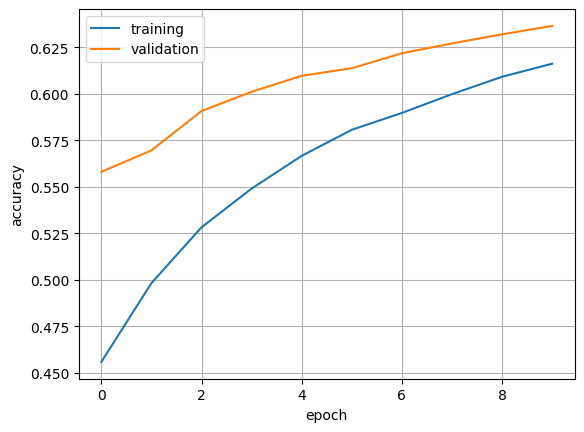

In [20]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.plot(accuracy_track['training'], label='training')
plt.plot(accuracy_track['validation'], label='validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid()
plt.legend()

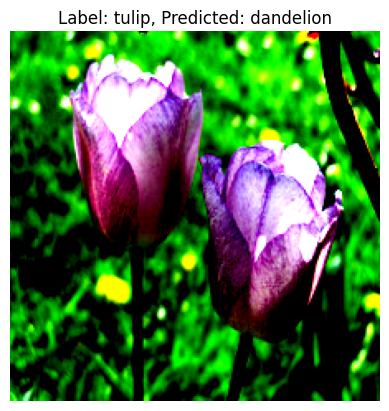

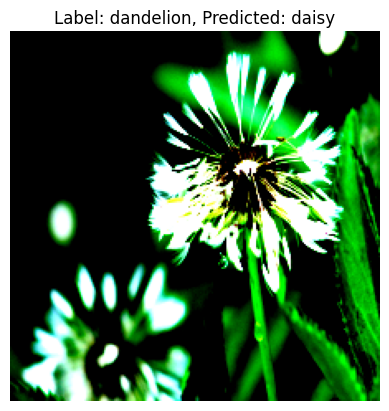

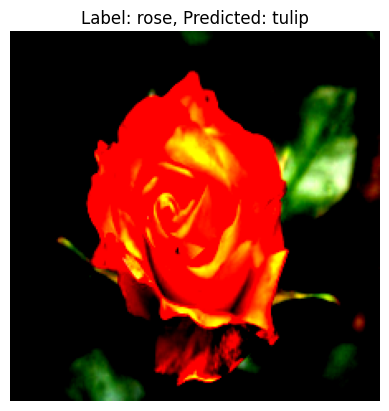

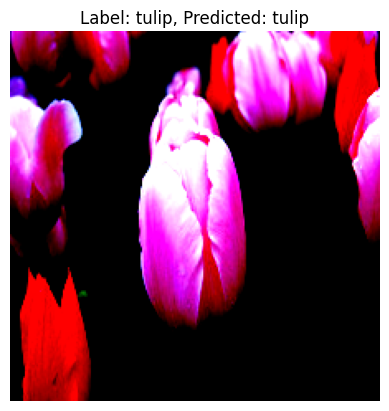

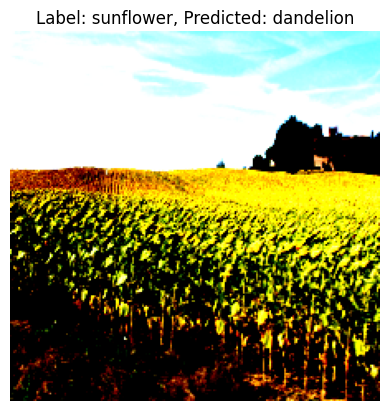

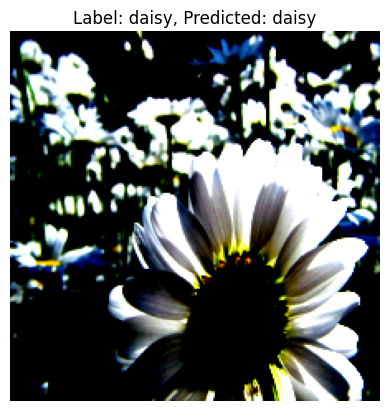

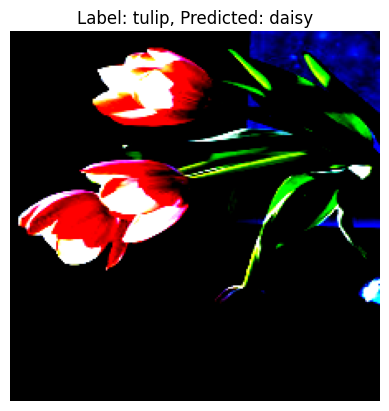

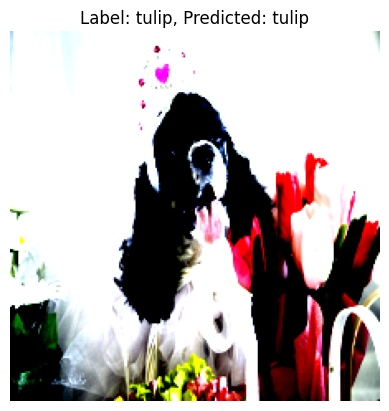

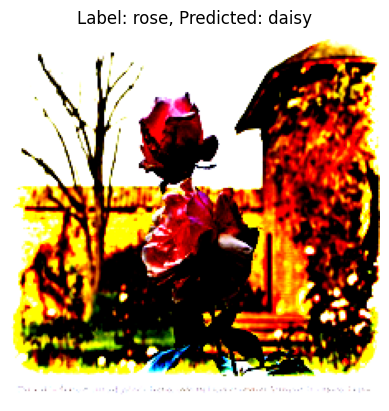

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

def predict_image(img, model):
    # Преобразование to a batch of 1
    xb = img.unsqueeze(0).to(device)
    # Получение прогнозов от модели
    yb = model(xb)
    # Выбираем индекс с наибольшей вероятностью
    _, preds  = torch.max(yb, dim=1)
    # Получение метки класса
    return dataset.classes[preds[0].item()]

for i in range(1,10):
  img, label = val_set[i]
  plt.imshow(img.clip(0,1).permute(1, 2, 0))
  plt.axis('off')
  plt.title('Label: {}, Predicted: {}'.format(dataset.classes[label],predict_image(img, my_model)))
  plt.show()